### Compare metadata between Read and our study

In [1]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
donor_metadata <- read.csv("../../../metadata_plots/01_donor_level_metadata.csv", row.names = 1)

In [4]:
# reverse the order of the studies, so that it shows up alphabetically from top to bottom
donor_metadata$study <- factor(donor_metadata$study, levels = rev(sort(unique(donor_metadata$study))) )

In [5]:
plots_dir <- "metadata_plots/"
dir.create(plots_dir)

In [12]:
# filter to just non-diseased donors

filt_donor_metadata <- donor_metadata[(donor_metadata$disease == "ND") & (donor_metadata$age_status == "postnatal"),  ]
dim(filt_donor_metadata)

[1] 154  10

### Our donor metadata

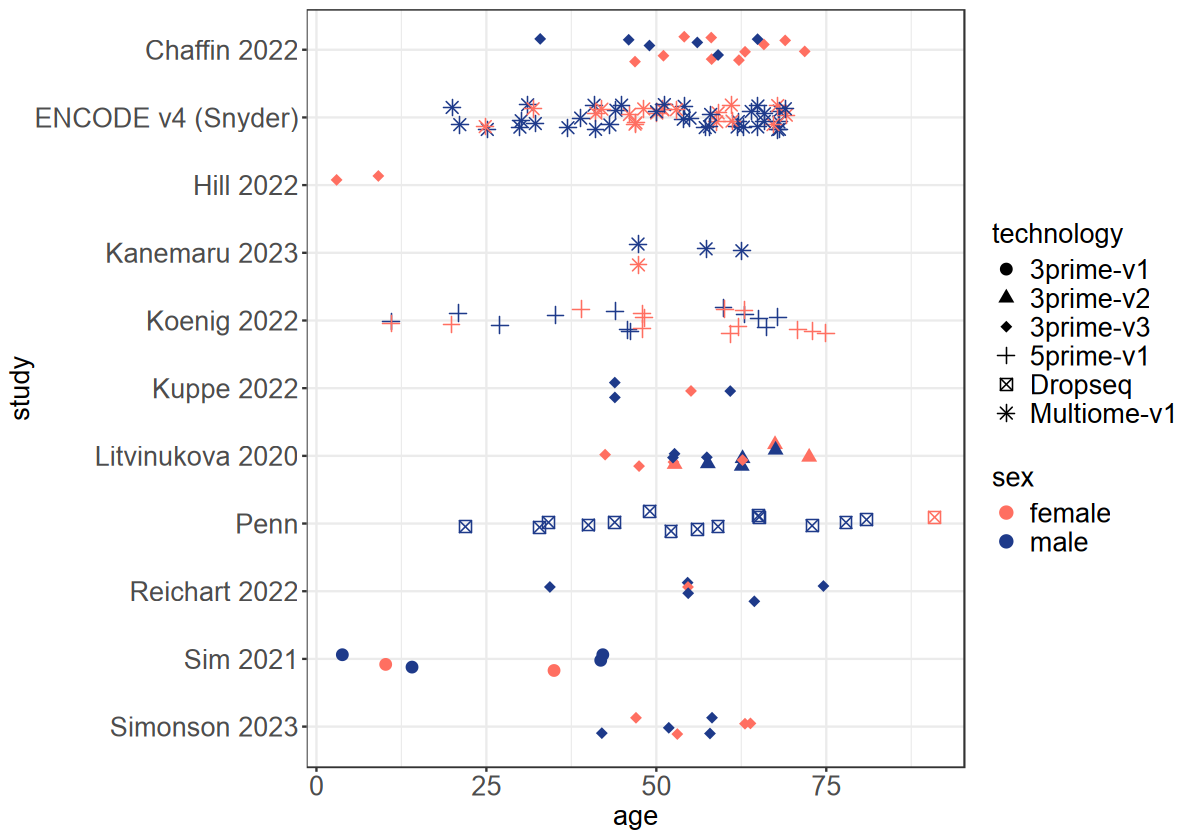

In [55]:
options(repr.plot.width = 10, repr.plot.height = 7)

color_palette <- c("male" = "#1E3A8A", "female" = "#FF6F61")

p1 <- ggplot(data = filt_donor_metadata, mapping = aes(x = age, y = study,
                                            color = sex, shape = technology)) + geom_jitter(size = 3, height = 0.2, width = 0.2) + scale_color_manual(values = color_palette) +
theme_bw() + theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16), 
         plot.title = element_text(size = 24, hjust = 0.5), 
         axis.title.x = element_text(size = 16),
         axis.title.y = element_text(size = 16),
         axis.text.x = element_text(size = 16),
         axis.text.y = element_text(size = 16),
         strip.text = element_text(size = 18)) + scale_shape_manual(values = c("3prime-v1" = 16, 
                                                                               "3prime-v2" = 17, 
                                                                               "3prime-v3" = 18, 
                                                                               "5prime-v1" = 3, 
                                                                               "Dropseq" = 7, 
                                                                               "Multiome-v1" = 8))

p1 

ggsave(p1, filename = paste0(plots_dir, "our_metadata_stripplot.pdf"), width = 10, height = 7)

In [45]:
dim(filt_donor_metadata)

[1] 154  10

### Read metadata

In [46]:
Read_metadata <- filt_donor_metadata[filt_donor_metadata$study %in% c("Koenig 2022", "Reichart 2022",
                                                                      "Chaffin 2022", "Litvinukova 2020"), ]

In [48]:
additional_Read_metadata <- read.table("00_Read_additional_donors.tsv", header=TRUE)

In [49]:
full_Read_metadata <- rbind(Read_metadata, additional_Read_metadata)

In [50]:
dim(full_Read_metadata)

[1] 76 10

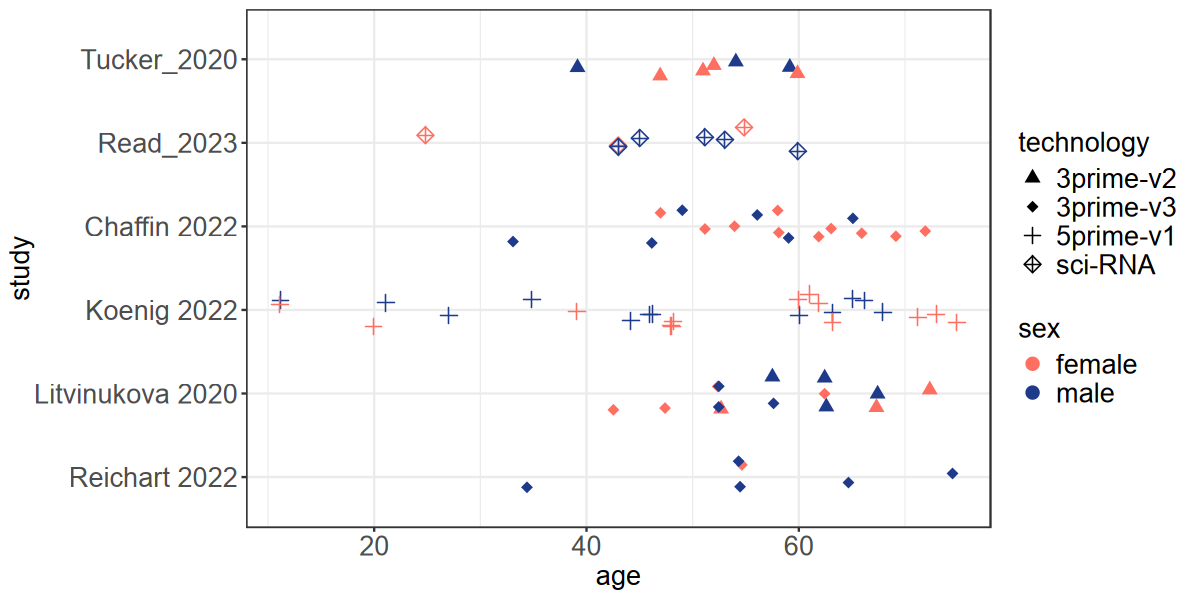

In [51]:
options(repr.plot.width = 10, repr.plot.height = 5)

color_palette <- c("male" = "#1E3A8A", "female" = "#FF6F61")

p1 <- ggplot(data = full_Read_metadata, mapping = aes(x = age, y = study,
                                            color = sex, shape = technology)) + geom_jitter(size = 3, height = 0.2, width = 0.2) + scale_color_manual(values = color_palette) +
theme_bw() + theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16), 
         plot.title = element_text(size = 24, hjust = 0.5), 
         axis.title.x = element_text(size = 16),
         axis.title.y = element_text(size = 16),
         axis.text.x = element_text(size = 16),
         axis.text.y = element_text(size = 16),
         strip.text = element_text(size = 18)) + scale_shape_manual(values = c("3prime-v1" = 16, 
                                                                               "3prime-v2" = 17, 
                                                                               "3prime-v3" = 18, 
                                                                               "5prime-v1" = 3, 
                                                                               "Dropseq" = 7, 
                                                                               "Multiome-v1" = 8,
                                                                              "sci-RNA" = 9))

p1 

ggsave(p1, filename = paste0(plots_dir, "Read_metadata_stripplot.pdf"), width = 10, height = 7)